In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [2]:
df = pd.read_csv('../data/spotify-tracks.csv', low_memory=False, index_col=0)
df.tail()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,"#mindfulness - Soft Rain for Mindful Meditation, Stress Relief Relaxation Music",Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,"#mindfulness - Soft Rain for Mindful Meditation, Stress Relief Relaxation Music",Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [3]:
df_original_size = df.shape[0]
df.drop_duplicates(subset=['track_name'], inplace=True)
df.reset_index(drop=True, inplace=True)
df.head(3)
numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 
                   'speechiness', 'acousticness', 'instrumentalness', 'liveness', 
                   'valence', 'tempo']

In [4]:
skewness_data = []
for col in numeric_cols:
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis()
    skewness_data.append({
        'Variable': col,
        'Asimetría (Skewness)': round(skew_val, 3),
        'Curtosis (Kurtosis)': round(kurt_val, 3),
        'Interpretación_Asimetría': 'Normal' if -0.5 <= skew_val <= 0.5 else ('Asimétrica izq.' if skew_val < -0.5 else 'Asimétrica der.')
    })

skew_df = pd.DataFrame(skewness_data)
print(skew_df.to_string(index=False))

        Variable  Asimetría (Skewness)  Curtosis (Kurtosis) Interpretación_Asimetría
      popularity                 0.075               -0.619                   Normal
     duration_ms                11.293              325.489          Asimétrica der.
    danceability                -0.395               -0.217                   Normal
          energy                -0.568               -0.612          Asimétrica izq.
        loudness                -1.943                5.320          Asimétrica izq.
     speechiness                 4.432               24.668          Asimétrica der.
    acousticness                 0.637               -1.092          Asimétrica der.
instrumentalness                 1.467                0.374          Asimétrica der.
        liveness                 1.998                3.672          Asimétrica der.
         valence                 0.130               -1.054                   Normal
           tempo                 0.166               -0.051      

generos: 113


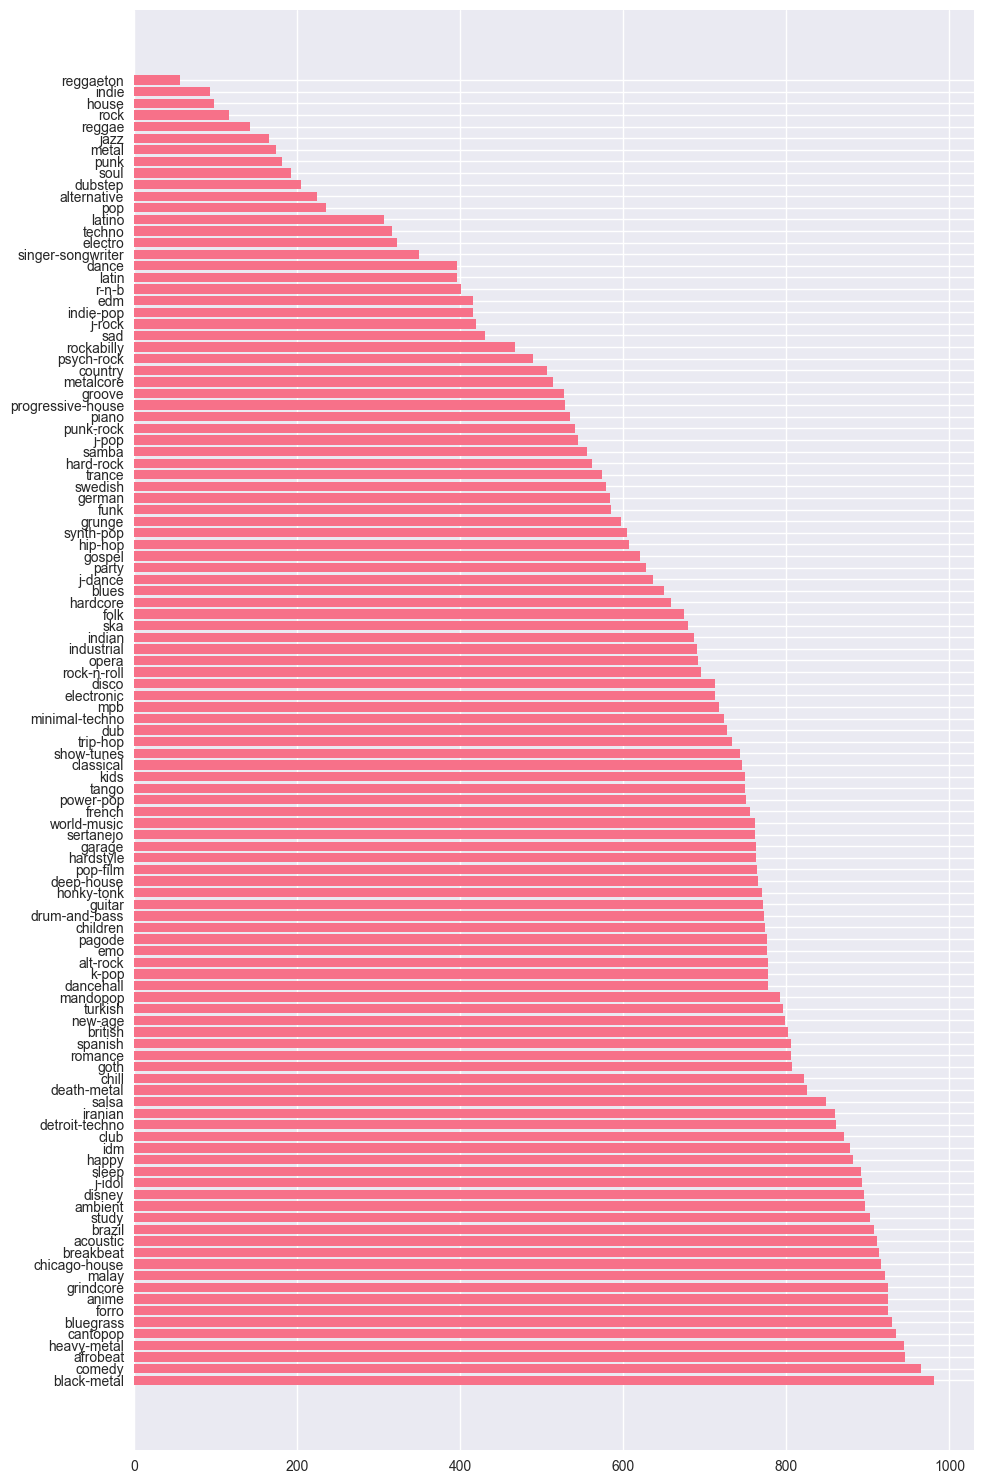

In [5]:
genre = df['track_genre'].value_counts()
a=genre.to_dict()
fig = plt.figure(figsize = (10, 15))
plt.barh(list(a.keys()),list(a.values()))
plt.tight_layout()
plt.gca()
print('generos:',len(a.keys()))

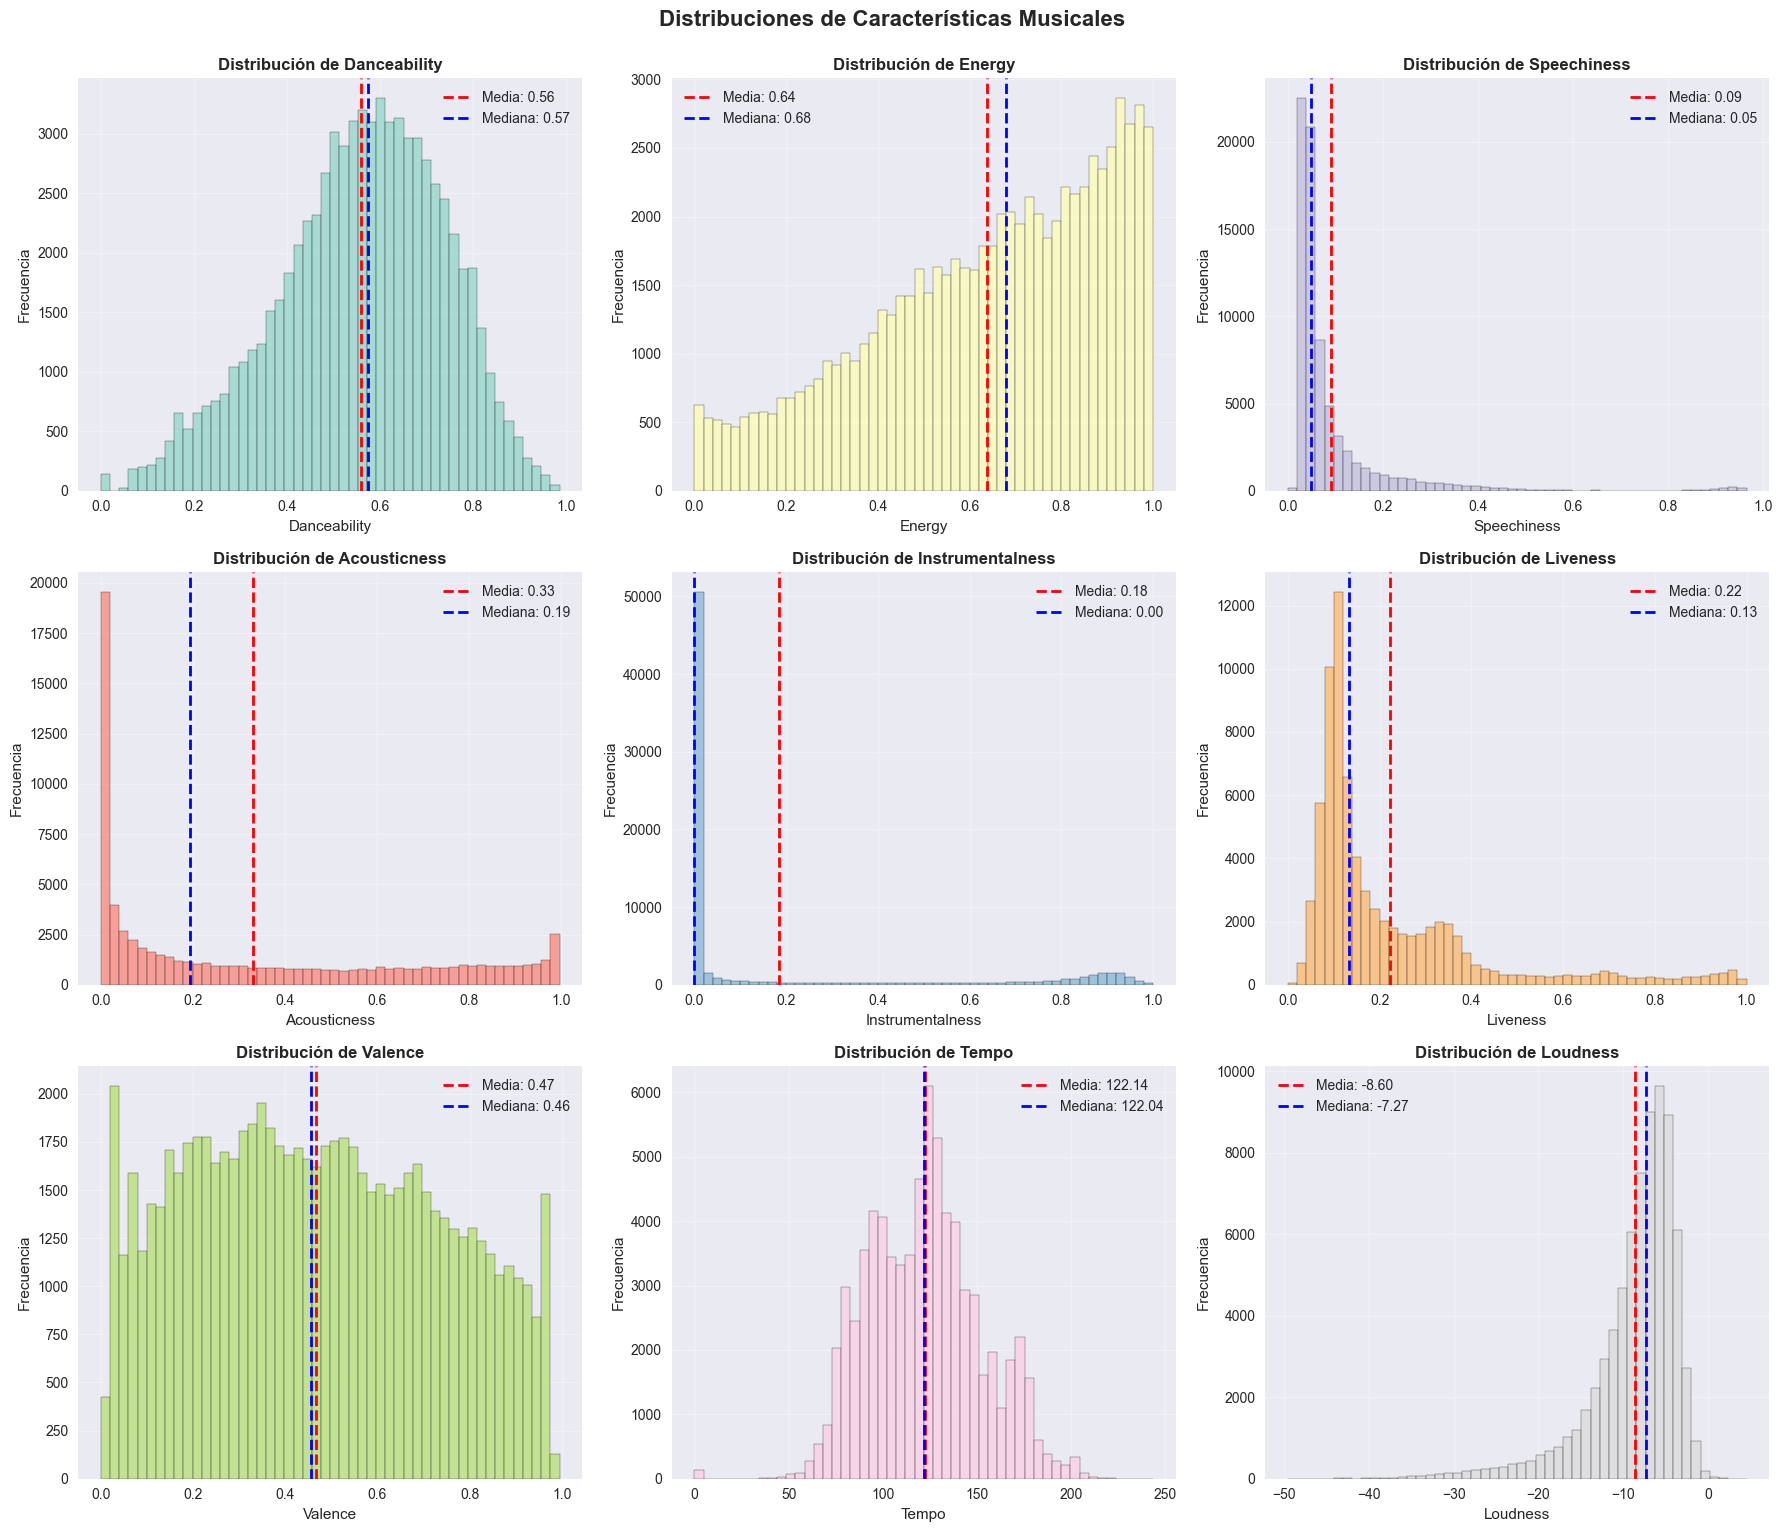

In [ ]:

audio_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                 'instrumentalness', 'liveness', 'valence']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, feature in enumerate(audio_features + ['tempo', 'loudness']):
    if i < len(axes):
        axes[i].hist(df[feature], bins=50, alpha=0.7, color=plt.cm.Set3(i), edgecolor='black')
        axes[i].set_title(f'Distribución de {feature.title()}', fontweight='bold')
        axes[i].set_xlabel(feature.title())
        axes[i].set_ylabel('Frecuencia')
        axes[i].grid(True, alpha=0.3)
        
        mean_val = df[feature].mean()
        median_val = df[feature].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
        axes[i].axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        axes[i].legend()


if len(audio_features + ['tempo', 'loudness']) < len(axes):
    for j in range(len(audio_features + ['tempo', 'loudness']), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribuciones de Características Musicales', fontsize=16, fontweight='bold', y=1.02)
plt.show()

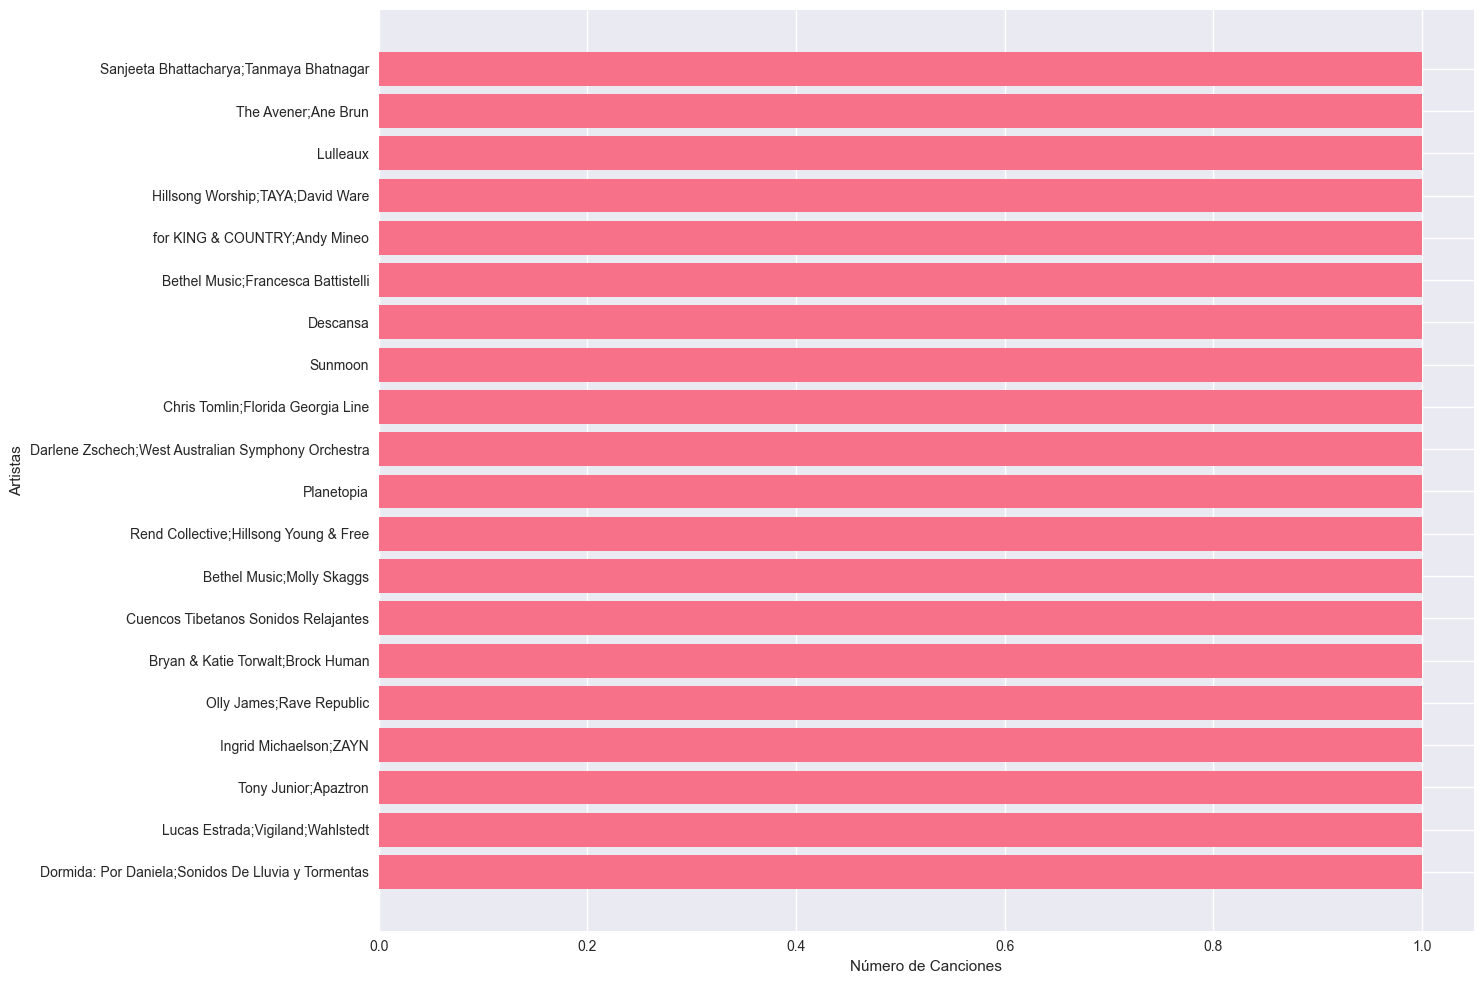

Artistas únicos: 29221


In [13]:
artists = df['artists'].value_counts().tail(20)  # Top 20 artists to avoid overcrowding
a = artists.to_dict()
fig = plt.figure(figsize=(15, 10))
plt.barh(list(a.keys()), list(a.values()))  # Horizontal bar for better readability
plt.xlabel('Número de Canciones')
plt.ylabel('Artistas')
plt.tight_layout()
plt.show()
print('Artistas únicos:', len(df['artists'].unique()))

In [ ]:
from scipy.stats import skew
for  i in audio_features+['tempo', 'loudness']:
    skewness = skew(df[i])
    print(f"columna {i} -> Coeficiente de sesgo: {abs(skewness):.3f}")

columna danceability -> Coeficiente de sesgo: 0.395
columna energy -> Coeficiente de sesgo: 0.568
columna speechiness -> Coeficiente de sesgo: 4.432
columna acousticness -> Coeficiente de sesgo: 0.637
columna instrumentalness -> Coeficiente de sesgo: 1.467
columna liveness -> Coeficiente de sesgo: 1.998
columna valence -> Coeficiente de sesgo: 0.130
columna tempo -> Coeficiente de sesgo: 0.166
columna loudness -> Coeficiente de sesgo: 1.943


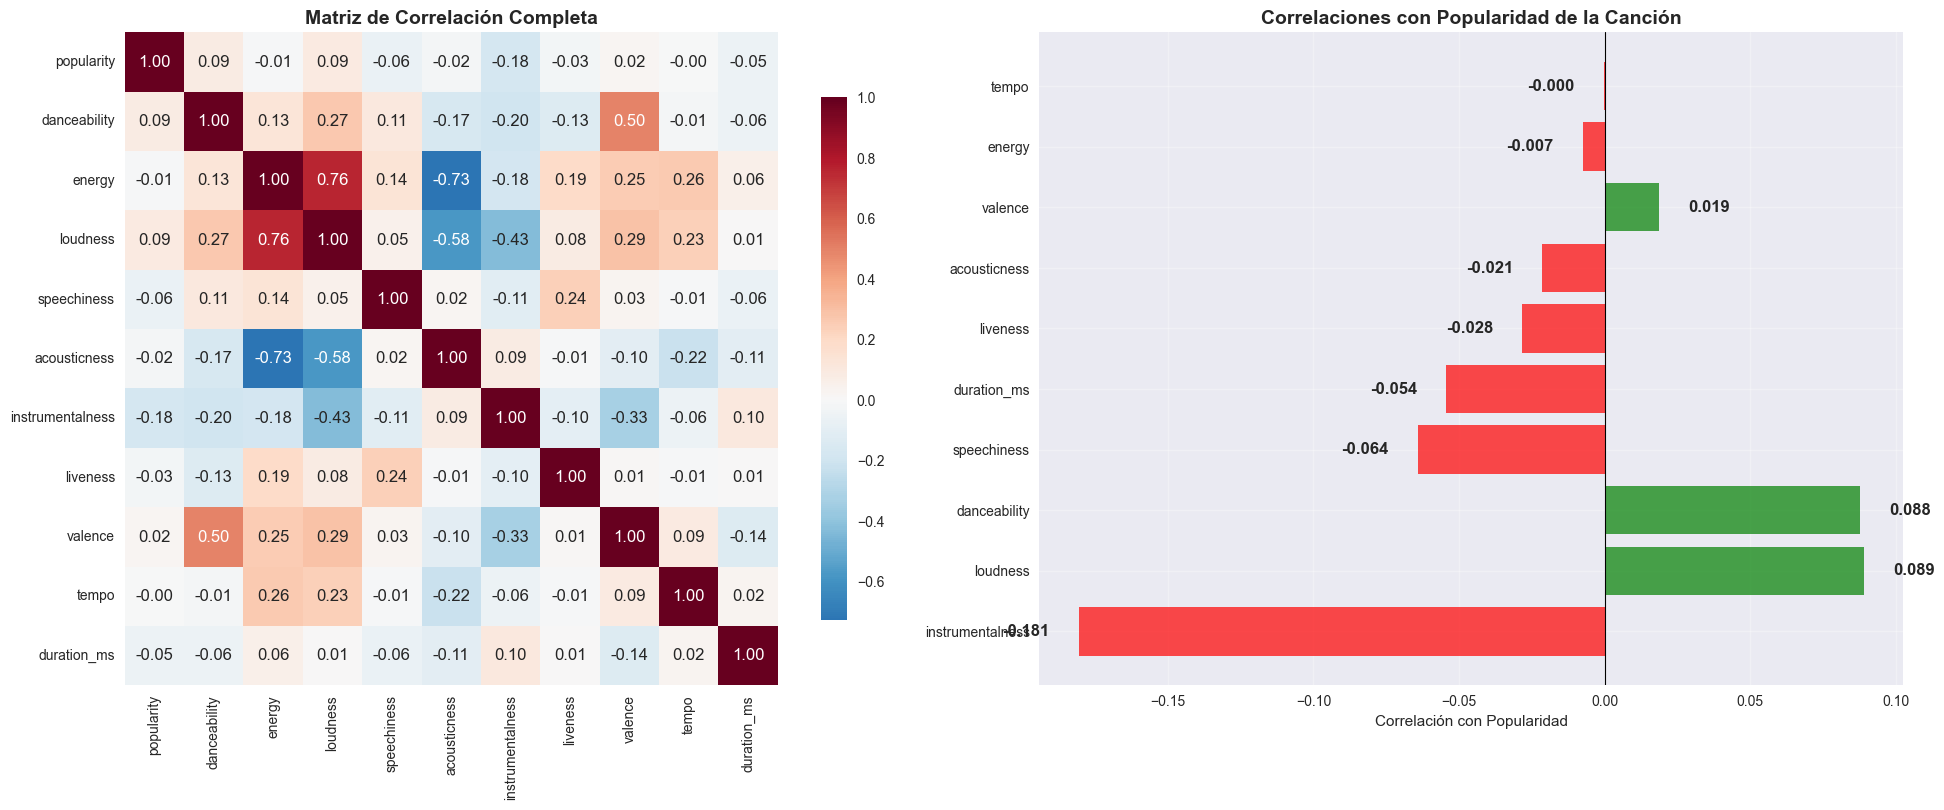

In [ ]:

numeric_features = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness', 
                   'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

corr_matrix = df[numeric_features].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))


sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', ax=ax1, cbar_kws={'shrink': 0.8})
ax1.set_title('Matriz de Correlación Completa', fontsize=14, fontweight='bold')


popularity_corr = corr_matrix['popularity'].drop('popularity').sort_values(key=abs, ascending=False)

colors = ['green' if x > 0 else 'red' for x in popularity_corr.values]
ax2.barh(range(len(popularity_corr)), popularity_corr.values, color=colors, alpha=0.7)
ax2.set_yticks(range(len(popularity_corr)))
ax2.set_yticklabels(popularity_corr.index)
ax2.set_xlabel('Correlación con Popularidad')
ax2.set_title('Correlaciones con Popularidad de la Canción', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

for i, v in enumerate(popularity_corr.values):
    ax2.text(v + (0.01 if v > 0 else -0.01), i, f'{v:.3f}', 
             va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()


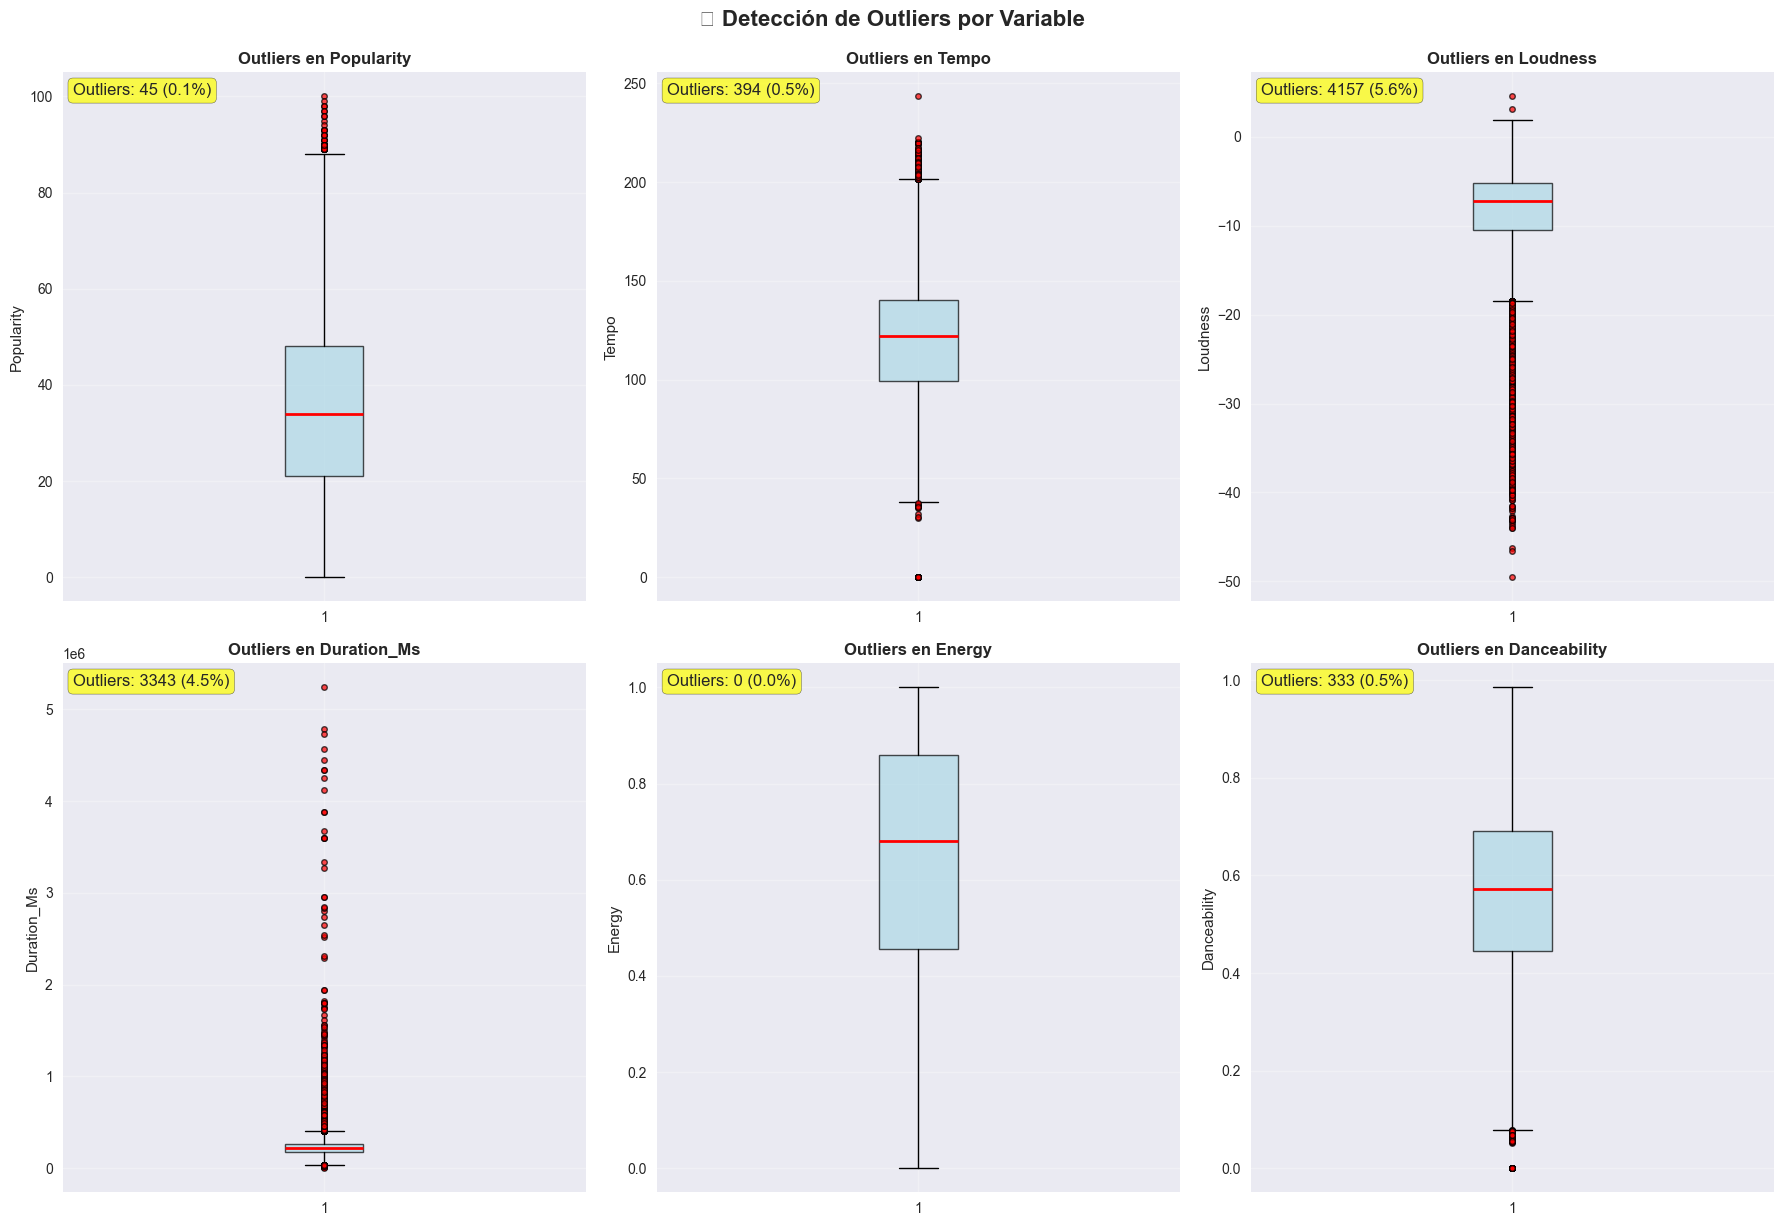

In [ ]:

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_features = ['popularity', 'tempo', 'loudness', 'duration_ms', 'energy', 'danceability']
outlier_summary = []

for feature in outlier_features:
    outliers, lower, upper = detect_outliers_iqr(df, feature)
    outlier_percentage = (len(outliers) / len(df)) * 100
    
    outlier_summary.append({
        'Variable': feature,
        'Total_Outliers': len(outliers),
        'Porcentaje': f"{outlier_percentage:.2f}%",
        'Límite_Inferior': f"{lower:.2f}",
        'Límite_Superior': f"{upper:.2f}",
        'Valor_Min_Outlier': f"{outliers[feature].min():.2f}" if len(outliers) > 0 else "N/A",
        'Valor_Max_Outlier': f"{outliers[feature].max():.2f}" if len(outliers) > 0 else "N/A"
    })


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(outlier_features):
    if i < len(axes):
        box_data = df[feature].dropna()
        bp = axes[i].boxplot([box_data], patch_artist=True, 
                            boxprops=dict(facecolor='lightblue', alpha=0.7),
                            medianprops=dict(color='red', linewidth=2),
                            flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.7))
        
        axes[i].set_title(f'Outliers en {feature.title()}', fontweight='bold')
        axes[i].set_ylabel(f'{feature.title()}')
        axes[i].grid(True, alpha=0.3)
        
        outliers, _, _ = detect_outliers_iqr(df, feature)
        axes[i].text(0.02, 0.98, f'Outliers: {len(outliers)} ({(len(outliers)/len(df)*100):.1f}%)', 
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.suptitle('📊 Detección de Outliers por Variable', fontsize=16, fontweight='bold', y=1.02)
plt.show()


In [ ]:
bins = [0, 30, 60, 80, 100]
labels = ["Poco popular", "Moderadamente popular", "Popular", "Muy popular"]
df["popularity_class"] = pd.cut(df["popularity"], bins=bins, labels=labels)

In [ ]:
df['artists'] = df['artists'].apply(lambda x: str(x).replace(';',' ').strip())
df['duration_ms']=df['duration_ms']/60000

In [ ]:
df['tempo_category'] = pd.cut(df['tempo'], bins=[0, 60, 90, 120, 200], 
                             labels=['lento', 'moderado', 'rápido', 'muy_rápido'])

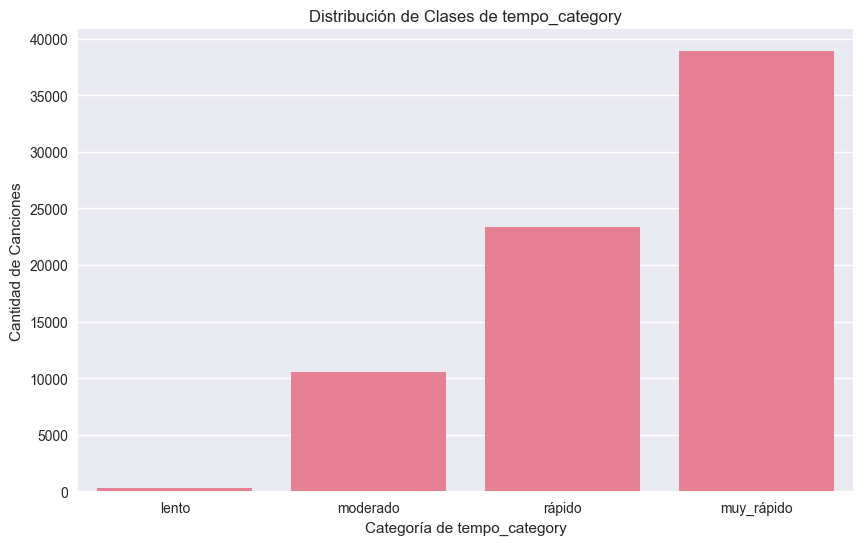


Proporciones:
popularity_class
Moderadamente popular    0.496119
Poco popular             0.404521
Popular                  0.094389
Muy popular              0.004972
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='tempo_category')
plt.title('Distribución de Clases de tempo_category')
plt.xlabel('Categoría de tempo_category')
plt.ylabel('Cantidad de Canciones')
plt.show()

print("\nProporciones:")
print(df['popularity_class'].value_counts(normalize=True))

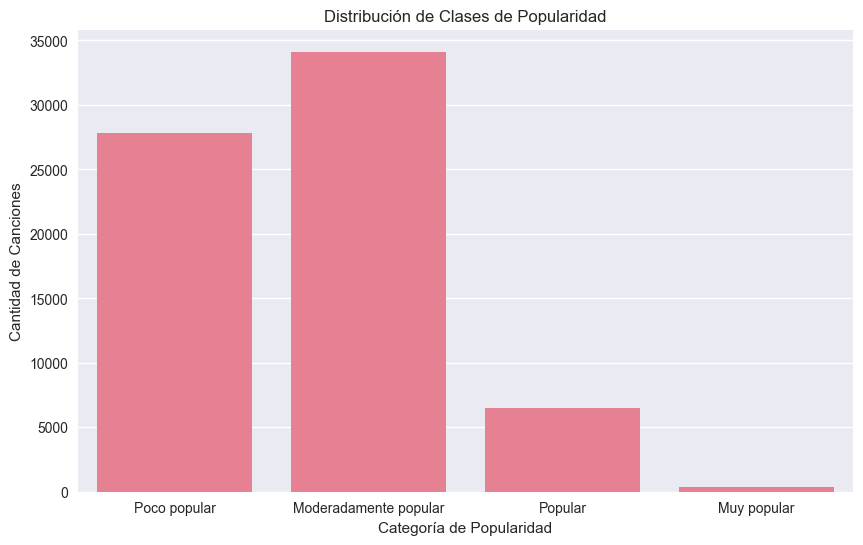


Proporciones:
popularity_class
Moderadamente popular    0.496119
Poco popular             0.404521
Popular                  0.094389
Muy popular              0.004972
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='popularity_class')
plt.title('Distribución de Clases de Popularidad')
plt.xlabel('Categoría de Popularidad')
plt.ylabel('Cantidad de Canciones')
plt.show()

print("\nProporciones:")
print(df['popularity_class'].value_counts(normalize=True))

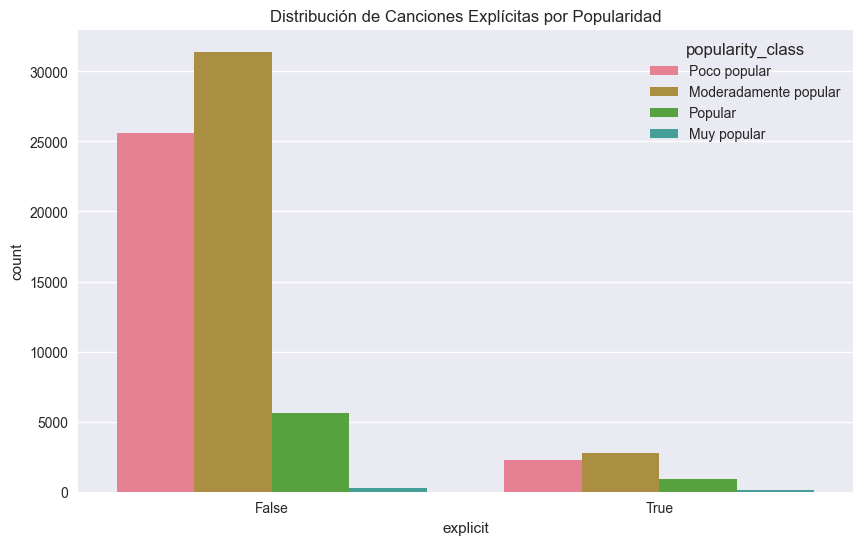

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='explicit', hue='popularity_class',)
plt.title('Distribución de Canciones Explícitas por Popularidad')
plt.show()

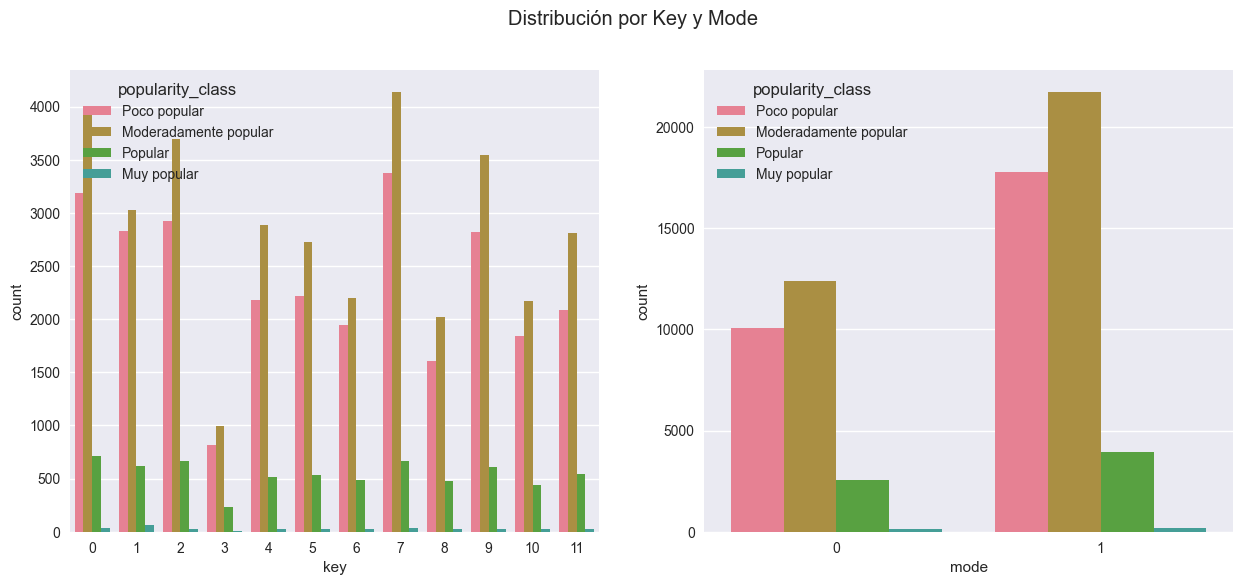

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=df, x='key', hue='popularity_class', ax=axes[0])
sns.countplot(data=df, x='mode', hue='popularity_class', ax=axes[1])
plt.suptitle('Distribución por Key y Mode')
plt.show()

In [ ]:
numeric_cols = ['popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 
               'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 
               'tempo', 'duration_ms']



genre_counts = df['track_genre'].value_counts()
print(f"Total de géneros únicos: {len(genre_counts)}")
print(f"  Género más común: {genre_counts.index[0]} ({genre_counts.iloc[0]:,} canciones)")
print(f"  Género menos común: {genre_counts.index[-1]} ({genre_counts.iloc[-1]:,} canciones)")

Total de géneros únicos: 113
  Género más común: black-metal (981 canciones)
  Género menos común: reggaeton (56 canciones)


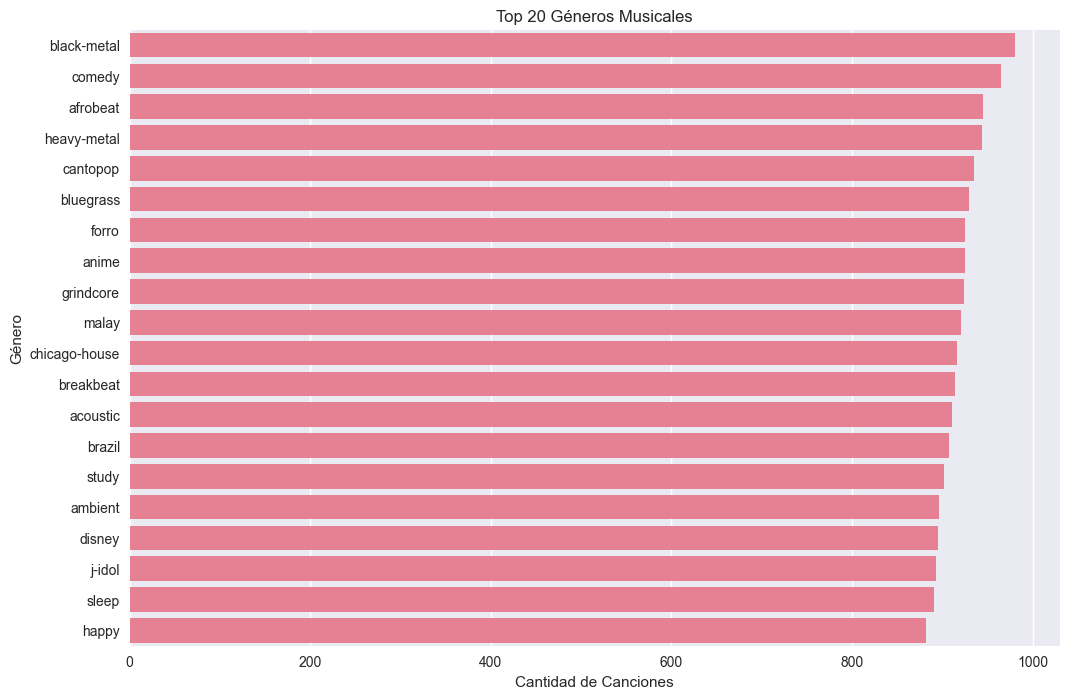

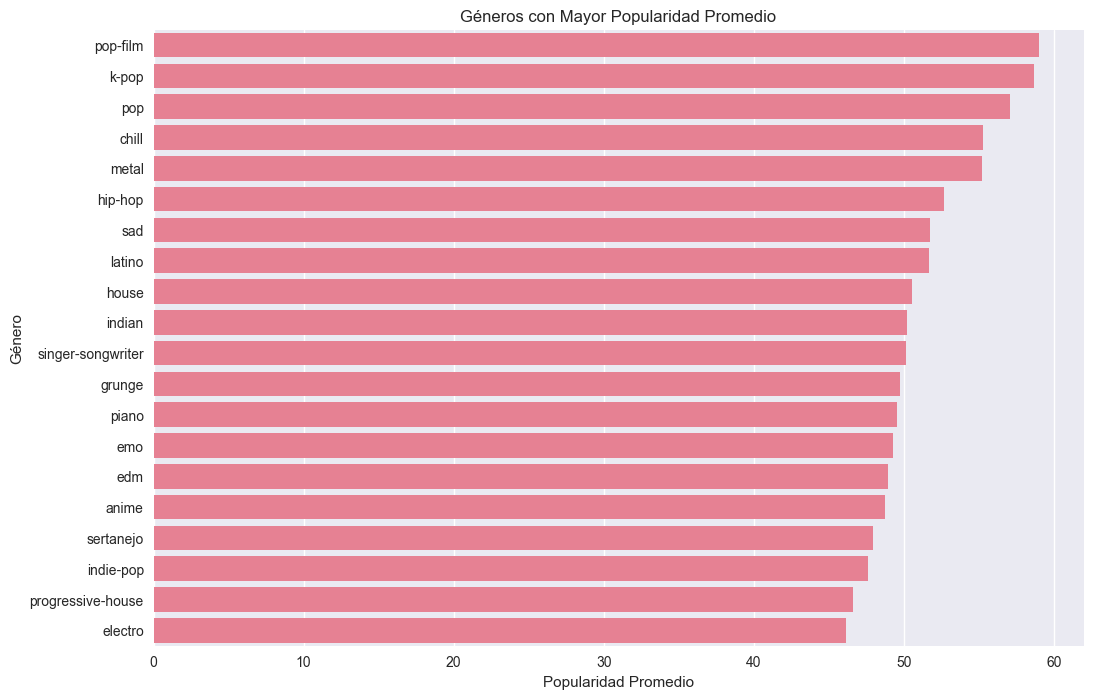

In [ ]:
top_genres = df['track_genre'].value_counts().head(20)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top 20 Géneros Musicales')
plt.xlabel('Cantidad de Canciones')
plt.ylabel('Género')
plt.show()

# Popularidad promedio por género
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index)
plt.title('Géneros con Mayor Popularidad Promedio')
plt.xlabel('Popularidad Promedio')
plt.ylabel('Género')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['track_id','artists','album_name','track_name','track_genre','popularity_class','popularity'])
y = df['popularity_class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['popularity_class'] = y.reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='popularity_class', 
                palette='viridis', alpha=0.6)
plt.title('PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Popularidad')
plt.show()

ValueError: Cannot cast object dtype to float64

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import plotly.express as px
df['artists'] = df['artists'].apply(lambda x: str(x).replace(';',' ').strip())
df['duration_min'] = df['duration_ms']/60000
X = df.drop(columns=['track_id','artists','album_name','track_name','track_genre','popularity_class','popularity'])
y = df['popularity_class']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['popularity_class'] = y.reset_index(drop=True)


fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='popularity_class',
    opacity=0.7,
    title=f'PCA 3D', 
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    }
)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30))
fig.show()

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01) 
X_selected = selector.fit_transform(X)

print(f"Features originales: {X.shape[1]}")
print(f"Features después de eliminar baja varianza: {X_selected.shape[1]}")

Features originales: 14
Features después de eliminar baja varianza: 14
